# Imports

In [ ]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
from scipy import stats as scipy_stats
from scipy.stats import wasserstein_distance, ks_2samp, f_oneway
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.titlesize': 11,
    'axes.grid': True,
    'grid.color': 'white',
    'grid.linewidth': 0.8,
    'axes.facecolor': '#f5f5f5',
    'figure.facecolor': 'white',
})

sys.path.insert(0, os.path.abspath('.'))

FEATURE_DIR = '../drc_prediction/training_set/DRC/feature/'
N_CHANNELS  = 9
CHANNEL_NAMES = [
    'macro_region', 'cell_density',
    'RUDY_long', 'RUDY_short', 'RUDY_pin_long',
    'congestion_eGR_H', 'congestion_eGR_V',
    'congestion_GR_H',  'congestion_GR_V',
]
print('Imports OK.')

Imports OK.


# Filename parsing and metadata loading

In [2]:
def parse_sample_name(filename: str) -> dict:
    """Parse a CircuitNet-N28 filename into its design-space components.

    Anchors from the right: the last 5 tokens always carry the prefixes
    c/u/m/p/f; the token at position -6 is macro_count; everything before
    that (after stripping any leading numeric id) is joined as the design name.

    Handles any number of hyphen-separated name parts, including:
      RISCY-a-1-c2-u0.7-m1-p1-f0.npy       → design=RISCY-a
      1-RISCY-a-1-c2-u0.7-m1-p1-f0.npy     → design=RISCY-a  (prefixed)
      zero-riscy-b-1-c2-u0.7-m1-p1-f0.npy  → design=zero-riscy-b
    """
    basename = filename.replace('.npy', '')
    parts = basename.split('-')
    # Strip leading numeric id if present (e.g. '1-RISCY-a-...')
    if parts[0].isdigit():
        parts = parts[1:]
    # Need at least: ≥1 design token + macro_count + c + u + m + p + f = 7
    if len(parts) < 7:
        raise ValueError(f'Cannot parse (too few tokens): {filename}')
    # Validate the 5 right-anchored suffix fields in order c, u, m, p, f
    for expected, token in zip(['c', 'u', 'm', 'p', 'f'], parts[-5:]):
        if not token.startswith(expected):
            raise ValueError(
                f'Cannot parse {filename}: expected prefix "{expected}", got "{token}"'
            )
    clock_str, util_str, macro_placement_raw, power_mesh_raw, filler_raw = parts[-5:]
    macro_count = parts[-6]
    design_name = '-'.join(parts[:-6])
    if not design_name:
        raise ValueError(f'Cannot parse {filename}: empty design name')
    return {
        'design_name':      design_name,
        'macro_count':      macro_count,
        'clock_ns':         float(clock_str[1:]),
        'utilization':      float(util_str[1:]),
        'macro_placement':  macro_placement_raw[1:],
        'power_mesh':       power_mesh_raw[1:],
        'filler_insertion': filler_raw[1:],
        'filename':         filename,
    }


feature_exists = os.path.isdir(FEATURE_DIR)
files = sorted(f for f in os.listdir(FEATURE_DIR) if f.endswith('.npy'))
print(f'Feature directory found: {len(files)} .npy files.')
records = []
for fname in files:
    try:
        records.append(parse_sample_name(fname))
    except Exception as e:
        print(f'  Skip {fname}: {e}')
df_meta = pd.DataFrame(records)

print(f'Samples: {len(df_meta)}')
print(df_meta.head())
print(df_meta.dtypes)

df_meta.loc[df_meta['macro_placement'].isin(['1','2','3','4']) == False, 'macro_placement'] = 1
df_meta['macro_placement'] = df_meta['macro_placement'].astype(int)

Feature directory found: 10242 .npy files.
Samples: 10242
    design_name macro_count  clock_ns  utilization macro_placement power_mesh  \
0       RISCY-a           1       2.0         0.70               1          1   
1       RISCY-a           1       2.0         0.70               2          2   
2       RISCY-a           1       2.0         0.85               2          3   
3       RISCY-a           2       5.0         0.75               2          1   
4  zero-riscy-b           3       2.0         0.85               1          6   

  filler_insertion                                    filename  
0                0            1-RISCY-a-1-c2-u0.7-m1-p1-f0.npy  
1                0           10-RISCY-a-1-c2-u0.7-m2-p2-f0.npy  
2                0         100-RISCY-a-1-c2-u0.85-m2-p3-f0.npy  
3                0        1000-RISCY-a-2-c5-u0.75-m2-p1-f0.npy  
4                1  10000-zero-riscy-b-3-c2-u0.85-m1-p6-f1.npy  
design_name          object
macro_count          object
clock_ns 

# Design Parameter Distributions

=== Categorical parameter distributions ===

design_name  (unique=6, balance=0.549):
design_name
zero-riscy-a    2042
RISCY-a         2003
RISCY-FPU-a     1969
RISCY-b         1858
RISCY-FPU-b     1248
zero-riscy-b    1122

macro_count  (unique=3, balance=0.800):
macro_count
1    3861
3    3291
2    3090

macro_placement  (unique=4, balance=0.206):
macro_placement
1    3422
2    3165
3    2950
4     705

power_mesh  (unique=8, balance=0.964):
power_mesh
6    1302
5    1298
7    1292
8    1287
1    1273
3    1271
4    1264
2    1255

filler_insertion  (unique=2, balance=0.749):
filler_insertion
1    5857
0    4385

=== Numerical parameter distributions ===

utilization:
count    10242.000000
mean         0.791349
std          0.068329
min          0.700000
25%          0.750000
50%          0.800000
75%          0.850000
max          0.900000
  Unique values: [0.7, 0.75, 0.8, 0.85, 0.9]

clock_ns:
count    10242.00000
mean         8.17809
std          7.39674
min          2.00000
25%   

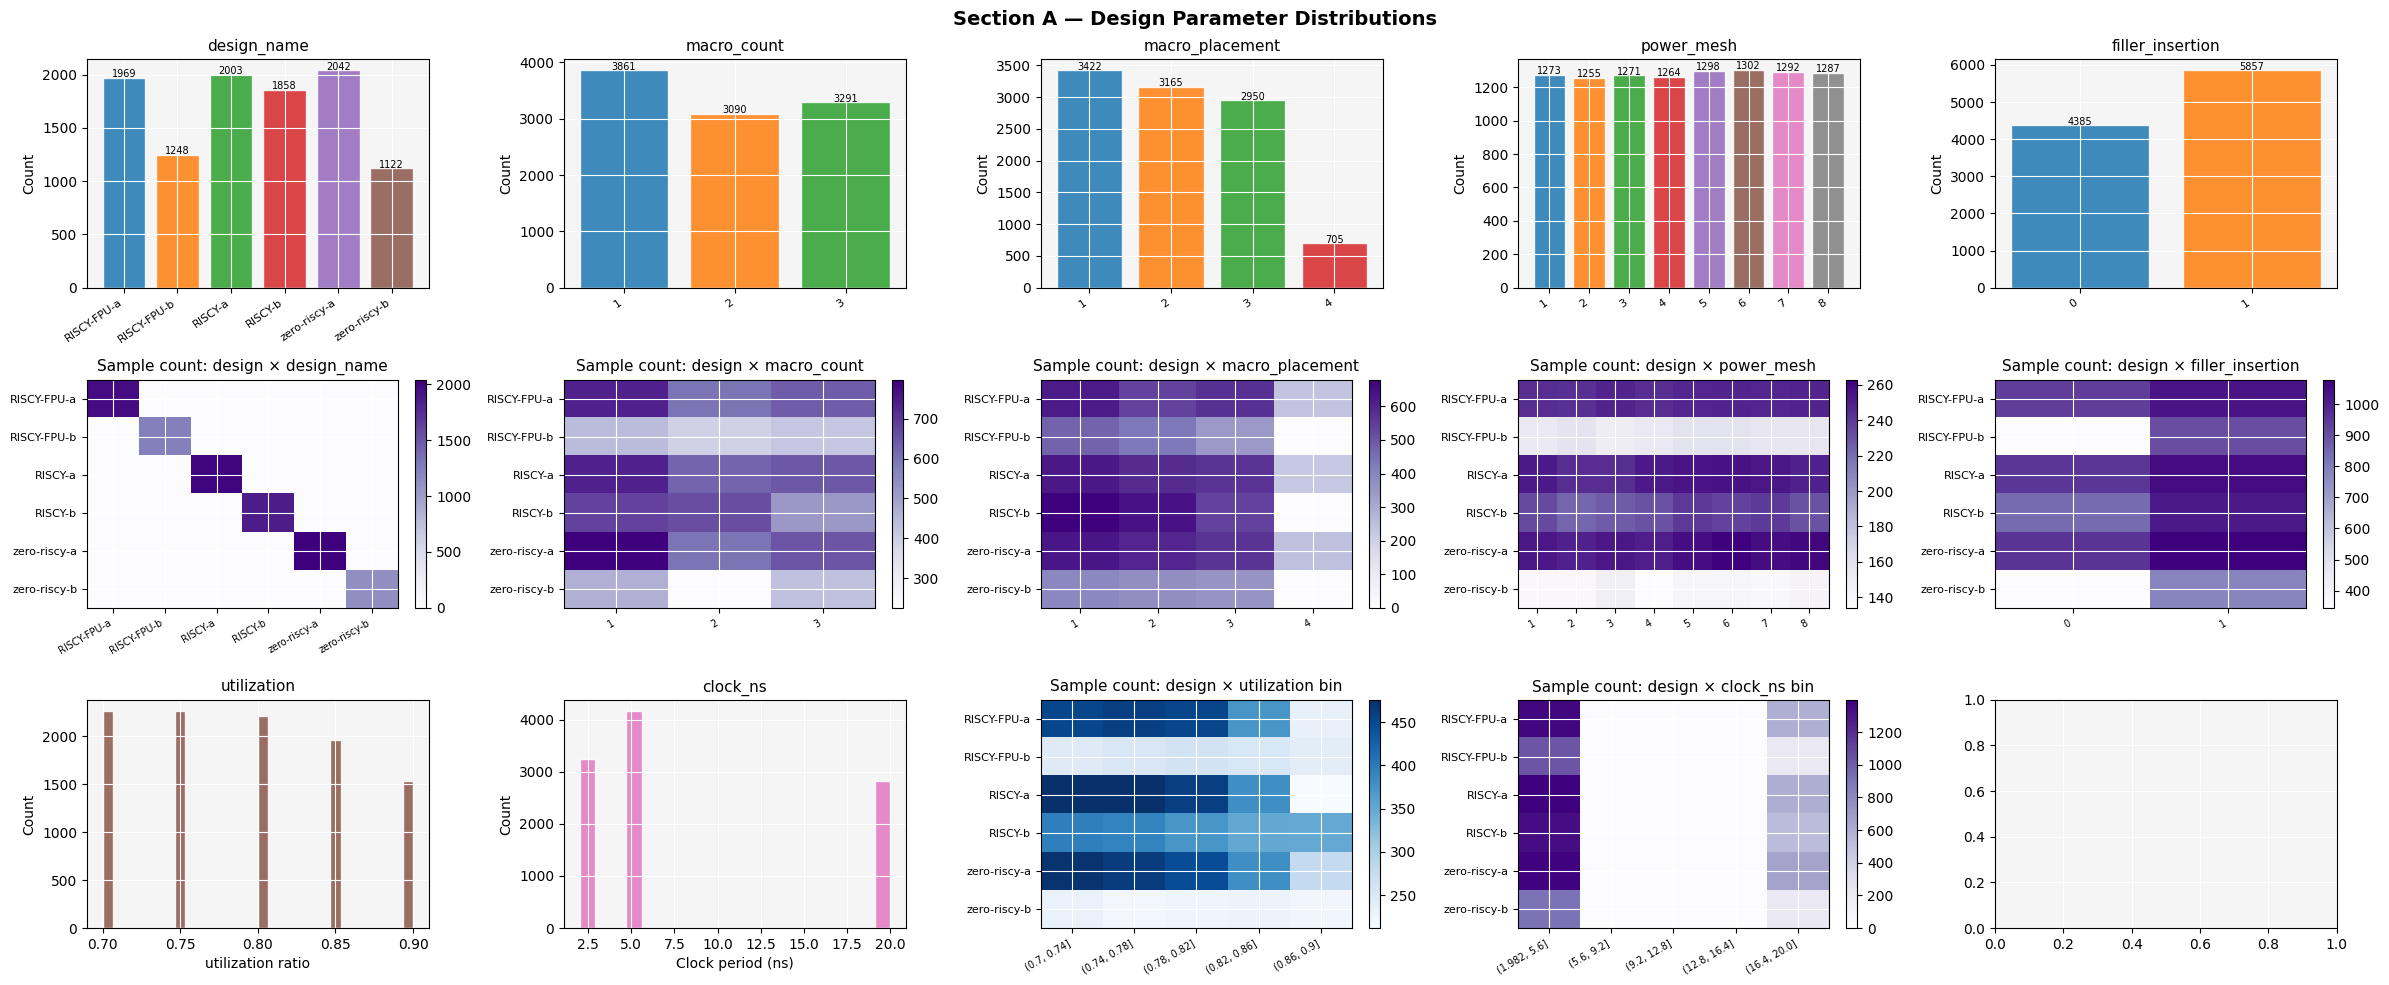

Unique parameter combinations: 10241 / 10242 samples


In [3]:

CAT_COLS = ['design_name','macro_count','macro_placement','power_mesh','filler_insertion']
NUM_COLS = ['utilization','clock_ns']

print('=== Categorical parameter distributions ===')
for col in CAT_COLS:
    vc = df_meta[col].value_counts()
    balance = vc.min() / vc.max()
    print(f'\n{col}  (unique={vc.shape[0]}, balance={balance:.3f}):')
    print(vc.to_string())

print('\n=== Numerical parameter distributions ===')
for col in NUM_COLS:
    print(f'\n{col}:')
    print(df_meta[col].describe().to_string())
    print('  Unique values:', sorted(df_meta[col].unique()))

fig, axes = plt.subplots(3, 5, figsize=(24, 10))
fig.suptitle('Section A — Design Parameter Distributions', fontsize=14, fontweight='bold')

cmap10 = mcm.get_cmap('tab10')

for ax, col in zip(axes[0], CAT_COLS):
    vc = df_meta[col].value_counts().sort_index()
    colors = [cmap10(i % 10) for i in range(len(vc))]
    bars = ax.bar(range(len(vc)), vc.values, color=colors, alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index, rotation=35, ha='right', fontsize=8)
    ax.set_title(col)
    ax.set_ylabel('Count')
    for bar, cnt in zip(bars, vc.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                str(cnt), ha='center', fontsize=7)

for ax, col in zip(axes[1], CAT_COLS):
    pivot2 = df_meta.groupby(['design_name', col]).size().unstack(fill_value=0)
    mat2 = pivot2.values.astype(float)
    im2 = ax.imshow(mat2, aspect='auto', cmap='Purples')
    ax.set_yticks(range(len(pivot2.index)))
    ax.set_yticklabels(pivot2.index, fontsize=8)
    ax.set_xticks(range(len(pivot2.columns)))
    ax.set_xticklabels([str(c) for c in pivot2.columns], rotation=30, ha='right', fontsize=7)
    ax.set_title(f'Sample count: design × {col}')
    plt.colorbar(im2, ax=ax, fraction=0.04)

# Utilization histogram
ax = axes[2][0]
ax.hist(df_meta['utilization'], bins=30, color=cmap10(5), alpha=0.85, edgecolor='white')
ax.set_title('utilization')
ax.set_xlabel('utilization ratio')
ax.set_ylabel('Count')

# Clock histogram
ax = axes[2][1]
ax.hist(df_meta['clock_ns'], bins=20, color=cmap10(6), alpha=0.85, edgecolor='white')
ax.set_title('clock_ns')
ax.set_xlabel('Clock period (ns)')
ax.set_ylabel('Count')

# Design × utilization sample counts heatmap
ax = axes[2][2]
util_bins = pd.cut(df_meta['utilization'], bins=5)
pivot = df_meta.groupby(['design_name', util_bins]).size().unstack(fill_value=0)
mat = pivot.values.astype(float)
im = ax.imshow(mat, aspect='auto', cmap='Blues')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([str(c) for c in pivot.columns], rotation=30, ha='right', fontsize=7)
ax.set_title('Sample count: design × utilization bin')
plt.colorbar(im, ax=ax, fraction=0.04)

# Design × clock sample counts heatmap
ax = axes[2][3]
clock_bins = pd.cut(df_meta['clock_ns'], bins=5)
pivot2 = df_meta.groupby(['design_name', clock_bins]).size().unstack(fill_value=0)
mat2 = pivot2.values.astype(float)
im2 = ax.imshow(mat2, aspect='auto', cmap='Purples')
ax.set_yticks(range(len(pivot2.index)))
ax.set_yticklabels(pivot2.index, fontsize=8)
ax.set_xticks(range(len(pivot2.columns)))
ax.set_xticklabels([str(c) for c in pivot2.columns], rotation=30, ha='right', fontsize=7)
ax.set_title('Sample count: design × clock_ns bin')
plt.colorbar(im2, ax=ax, fraction=0.04)

plt.tight_layout()
plt.show()

# Design space coverage
all_cols = CAT_COLS + ['clock_ns', 'utilization']
unique_combos = df_meta[all_cols].drop_duplicates()
print(f'Unique parameter combinations: {len(unique_combos)} / {len(df_meta)} samples')

# Section B — Attribute Dependency Analysis

Marginal distributions (Section A) tell us how much mass each attribute has.
They do not tell us whether attributes are **entangled** with one another.

For partitioning we need to know two things:

1. Which attributes are **proxies of `design_name`** (i.e. largely determined
   by the design). These cannot be used as an independent partition axis —
   they *are* the design axis.
2. Which attributes are **orthogonal to `design_name`** (internal flow
   variants: fabrication knobs turned inside a single team's flow). These
   are not client separators; they cannot induce inter-client heterogeneity.

Preregistered thresholds on the bias-corrected Cramér's V:

- **V ≥ 0.40** → design proxy (joins the primary axis).
- **V ≤ 0.15** → orthogonal (flow variant, drop from partitioning).
- **0.15 < V < 0.40** → moderate, discuss case-by-case.

All p-values will be effectively zero (N = 10,242), so decisions are made on
**effect size only**.

The section also checks whether the marginal association between `clock_ns`
and `utilization` survives conditioning on `design_name`, to validate that
the intended two-axis persona construction (design × clock/util) is
well-defined.

=== Pairwise Cramér's V (bias-corrected) ===
                  design_name  macro_count  macro_placement  power_mesh  filler_insertion  clock_ns  utilization
design_name               NaN        0.063            0.132         0.0             0.152     0.145        0.050
macro_count             0.063          NaN            0.035         0.0             0.052     0.043        0.030
macro_placement         0.132        0.035              NaN         0.0             0.316     0.061        0.035
power_mesh              0.000        0.000            0.000         NaN             0.000     0.000        0.000
filler_insertion        0.152        0.052            0.316         0.0               NaN     0.107        0.137
clock_ns                0.145        0.043            0.061         0.0             0.107       NaN        0.019
utilization             0.050        0.030            0.035         0.0             0.137     0.019          NaN

=== Association with design_name (ranked) ===
  fi

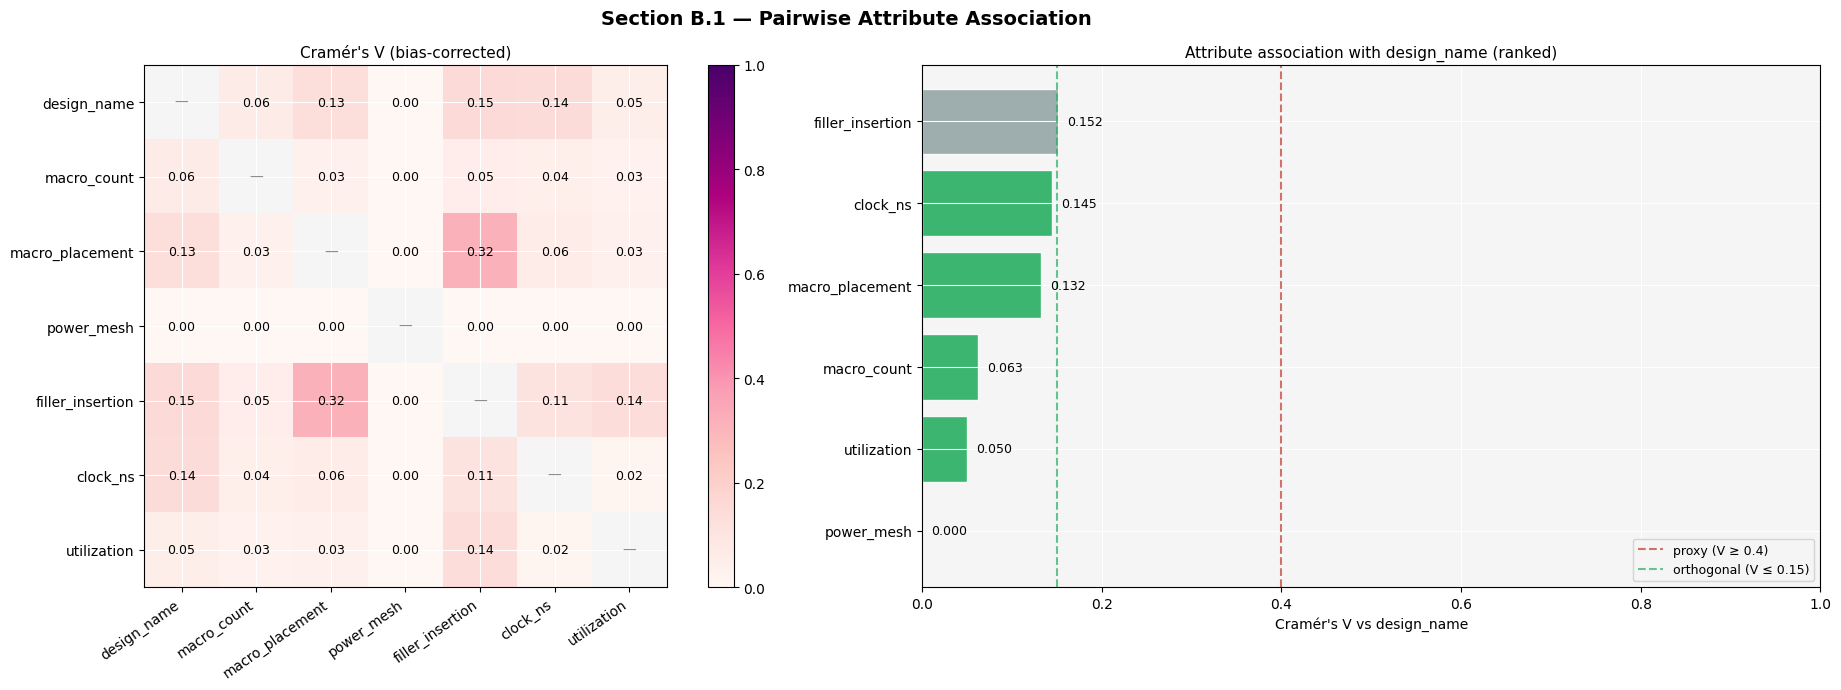

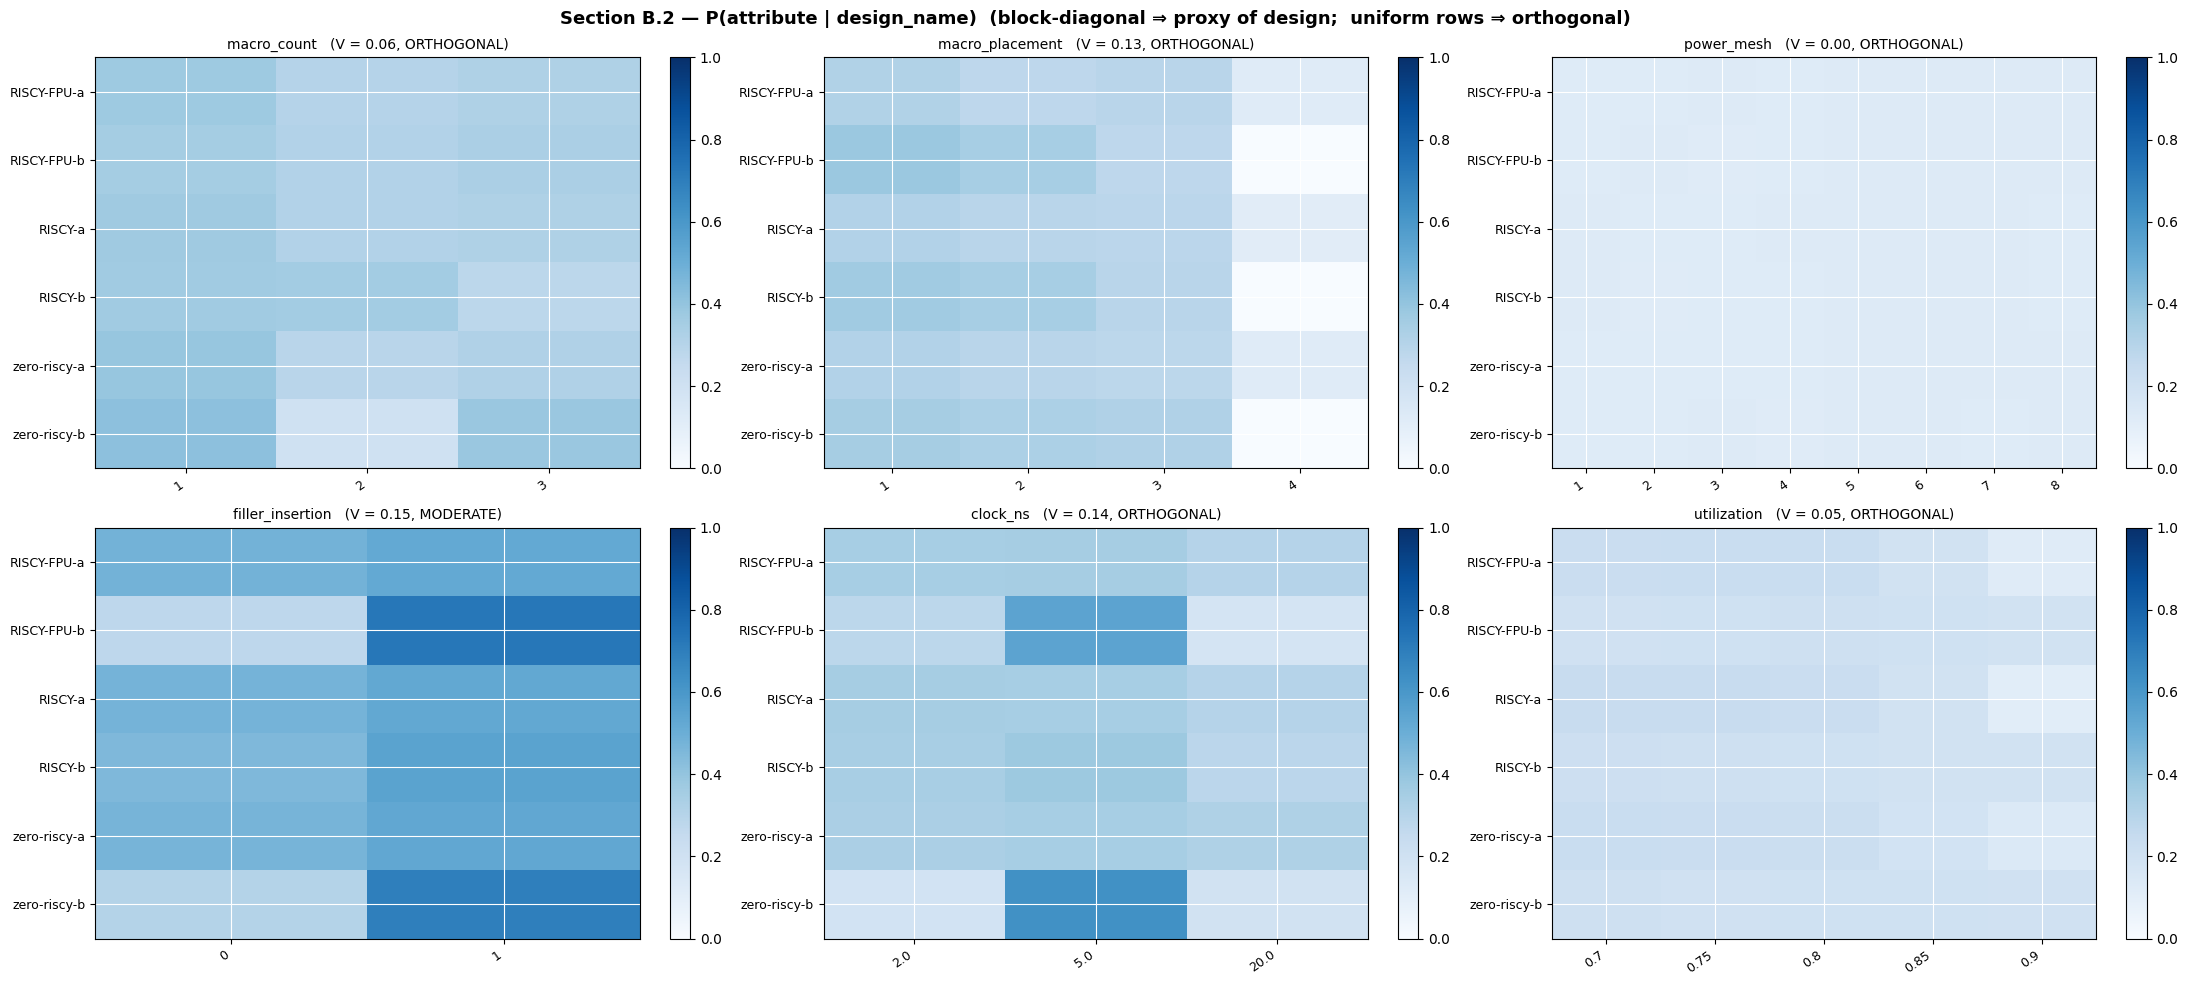


=== Conditional check: clock_ns ↔ utilization ===
Marginal V(clock_ns, utilization) = 0.019
Within-design V:
  RISCY-FPU-a          0.000
  RISCY-a              0.000
  RISCY-b              0.000
  zero-riscy-a         0.000
  zero-riscy-b         0.000
  RISCY-FPU-b          0.067
Mean within-design V      = 0.011


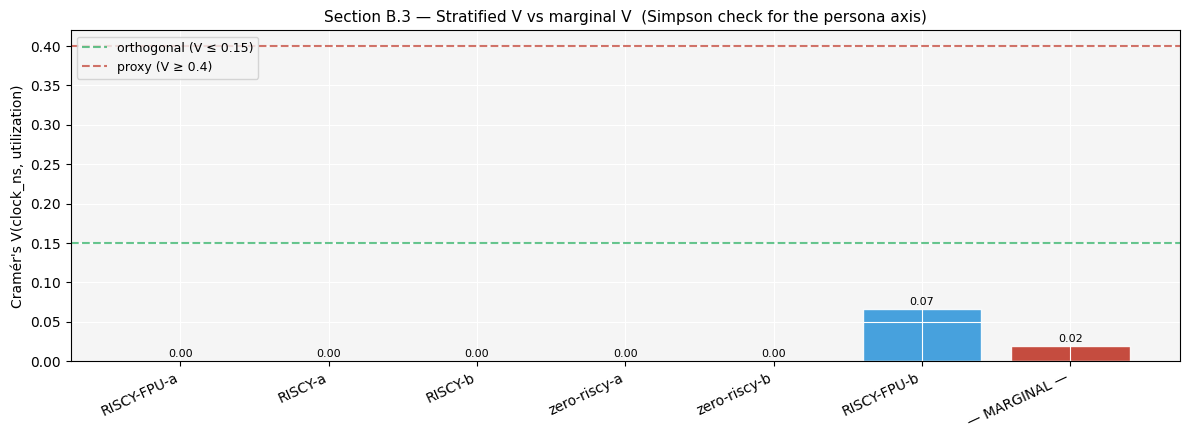


=== Interpretation for Phase 3 axis construction ===
Primary axis (design + proxies)      : design_name + []
Secondary-axis candidates (moderate) : ['filler_insertion']
Flow variants (drop from partition)  : ['clock_ns', 'macro_placement', 'macro_count', 'utilization', 'power_mesh']

[Weak marginal]  clock_ns and utilization are already near-independent
  at the marginal level; no Simpson concern for the persona axis.


In [4]:
ATTRS = ['design_name', 'macro_count', 'macro_placement', 'power_mesh',
         'filler_insertion', 'clock_ns', 'utilization']

PROXY_THR = 0.40
ORTHO_THR = 0.15


def cramers_v(x, y, bias_correction=True):
    """Bias-corrected Cramér's V (Bergsma & Wicher, 2013). Returns V in [0, 1]."""
    ct = pd.crosstab(x, y)
    chi2, _, _, _ = scipy_stats.chi2_contingency(ct)
    n = ct.values.sum()
    r, k = ct.shape
    if min(r, k) < 2 or n == 0:
        return np.nan
    if not bias_correction:
        return float(np.sqrt(chi2 / (n * (min(r, k) - 1))))
    phi2 = chi2 / n
    phi2_corr = max(0.0, phi2 - ((r - 1) * (k - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(k_corr - 1, r_corr - 1)
    if denom <= 0:
        return 0.0
    return float(np.sqrt(phi2_corr / denom))


# -- B.1  Pairwise Cramér's V matrix + chi² p-values -------------------------
V = pd.DataFrame(np.nan, index=ATTRS, columns=ATTRS, dtype=float)
P = pd.DataFrame(np.nan, index=ATTRS, columns=ATTRS, dtype=float)
for a in ATTRS:
    for b in ATTRS:
        if a == b:
            continue
        ct = pd.crosstab(df_meta[a], df_meta[b])
        chi2, p, _, _ = scipy_stats.chi2_contingency(ct)
        V.loc[a, b] = cramers_v(df_meta[a], df_meta[b])
        P.loc[a, b] = p

print("=== Pairwise Cramér's V (bias-corrected) ===")
print(V.round(3).to_string())

design_assoc = V.loc['design_name'].drop('design_name').sort_values(ascending=False)
print('\n=== Association with design_name (ranked) ===')
for attr, v in design_assoc.items():
    band = ('PROXY      ' if v >= PROXY_THR else
            'ORTHOGONAL ' if v <= ORTHO_THR else
            'MODERATE   ')
    print(f'  {attr:20s} V={v:.3f}   p={P.loc["design_name", attr]:.2e}   {band}')


# -- Figure 1: V heatmap + ranked bar chart ---------------------------------
fig1, (ax_hm, ax_bar) = plt.subplots(
    1, 2, figsize=(20, 7), gridspec_kw={'width_ratios': [1, 1.1]}
)
fig1.suptitle('Section B.1 — Pairwise Attribute Association', fontsize=14, fontweight='bold')

Vplot = V.values.astype(float)
im = ax_hm.imshow(Vplot, cmap='RdPu', vmin=0, vmax=1)
ax_hm.set_xticks(range(len(ATTRS)))
ax_hm.set_xticklabels(ATTRS, rotation=35, ha='right')
ax_hm.set_yticks(range(len(ATTRS)))
ax_hm.set_yticklabels(ATTRS)
for i in range(len(ATTRS)):
    for j in range(len(ATTRS)):
        if np.isnan(Vplot[i, j]):
            ax_hm.text(j, i, '—', ha='center', va='center', color='#888', fontsize=10)
        else:
            ax_hm.text(j, i, f'{Vplot[i, j]:.2f}', ha='center', va='center',
                       color='white' if Vplot[i, j] > 0.55 else 'black', fontsize=9)
ax_hm.set_title("Cramér's V (bias-corrected)")
plt.colorbar(im, ax=ax_hm, fraction=0.045)

colors = ['#c0392b' if v >= PROXY_THR else
          '#27ae60' if v <= ORTHO_THR else
          '#95a5a6' for v in design_assoc.values]
bars = ax_bar.barh(range(len(design_assoc)), design_assoc.values,
                   color=colors, alpha=0.9, edgecolor='white')
ax_bar.set_yticks(range(len(design_assoc)))
ax_bar.set_yticklabels(design_assoc.index)
ax_bar.invert_yaxis()
ax_bar.axvline(PROXY_THR, color='#c0392b', linestyle='--', alpha=0.7,
               label=f'proxy (V ≥ {PROXY_THR})')
ax_bar.axvline(ORTHO_THR, color='#27ae60', linestyle='--', alpha=0.7,
               label=f'orthogonal (V ≤ {ORTHO_THR})')
ax_bar.set_xlim(0, 1)
ax_bar.set_xlabel("Cramér's V vs design_name")
ax_bar.set_title('Attribute association with design_name (ranked)')
for bar, v in zip(bars, design_assoc.values):
    ax_bar.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{v:.3f}', va='center', fontsize=9)
ax_bar.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()


# -- Figure 2: row-normalized contingency P(attribute | design) --------------
other_attrs = [a for a in ATTRS if a != 'design_name']  # 6 items → 2×3 grid
fig2, axes2 = plt.subplots(2, 3, figsize=(22, 10))
fig2.suptitle('Section B.2 — P(attribute | design_name)  '
              '(block-diagonal ⇒ proxy of design;  uniform rows ⇒ orthogonal)',
              fontsize=13, fontweight='bold')

for ax, attr in zip(axes2.ravel(), other_attrs):
    ct = pd.crosstab(df_meta['design_name'], df_meta[attr])
    row_norm = ct.div(ct.sum(axis=1), axis=0)
    im2 = ax.imshow(row_norm.values, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    ax.set_yticks(range(len(row_norm.index)))
    ax.set_yticklabels(row_norm.index, fontsize=9)
    ax.set_xticks(range(len(row_norm.columns)))
    ax.set_xticklabels([str(c) for c in row_norm.columns],
                       rotation=35, ha='right', fontsize=9)
    v_val = V.loc['design_name', attr]
    band = ('PROXY' if v_val >= PROXY_THR else
            'ORTHOGONAL' if v_val <= ORTHO_THR else
            'MODERATE')
    ax.set_title(f'{attr}   (V = {v_val:.2f}, {band})', fontsize=10)
    plt.colorbar(im2, ax=ax, fraction=0.045)

plt.tight_layout()
plt.show()


# -- B.3  Stratified Cramér's V for clock_ns ↔ utilization within design -----
v_marginal = cramers_v(df_meta['clock_ns'], df_meta['utilization'])
within = {}
for d, group in df_meta.groupby('design_name'):
    if group['clock_ns'].nunique() > 1 and group['utilization'].nunique() > 1:
        within[d] = cramers_v(group['clock_ns'], group['utilization'])
    else:
        within[d] = np.nan
within_series = pd.Series(within).sort_values()

print('\n=== Conditional check: clock_ns ↔ utilization ===')
print(f'Marginal V(clock_ns, utilization) = {v_marginal:.3f}')
print('Within-design V:')
for d, v in within_series.items():
    print(f'  {d:20s} {v:.3f}')
print(f'Mean within-design V      = {np.nanmean(list(within_series.values)):.3f}')

fig3, ax3 = plt.subplots(1, 1, figsize=(12, 4.5))
xs = list(within_series.index) + ['— MARGINAL —']
ys = list(within_series.values) + [v_marginal]
bar_colors = ['#3498db'] * len(within_series) + ['#c0392b']
bars = ax3.bar(range(len(xs)), ys, color=bar_colors, alpha=0.9, edgecolor='white')
ax3.set_xticks(range(len(xs)))
ax3.set_xticklabels(xs, rotation=25, ha='right')
ax3.set_ylabel("Cramér's V(clock_ns, utilization)")
ax3.axhline(ORTHO_THR, color='#27ae60', linestyle='--', alpha=0.7,
            label=f'orthogonal (V ≤ {ORTHO_THR})')
ax3.axhline(PROXY_THR, color='#c0392b', linestyle='--', alpha=0.7,
            label=f'proxy (V ≥ {PROXY_THR})')
ax3.set_title('Section B.3 — Stratified V vs marginal V  '
              '(Simpson check for the persona axis)')
for bar, v in zip(bars, ys):
    if not np.isnan(v):
        ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{v:.2f}', ha='center', fontsize=8)
ax3.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


# -- Interpretation for Phase 3 ---------------------------------------------
proxies    = [a for a, v in design_assoc.items() if v >= PROXY_THR]
orthogonal = [a for a, v in design_assoc.items() if v <= ORTHO_THR]
moderate   = [a for a, v in design_assoc.items() if ORTHO_THR < v < PROXY_THR]

print('\n=== Interpretation for Phase 3 axis construction ===')
print(f'Primary axis (design + proxies)      : design_name + {proxies}')
print(f'Secondary-axis candidates (moderate) : {moderate}')
print(f'Flow variants (drop from partition)  : {orthogonal}')

mean_within = np.nanmean(list(within_series.values))
if mean_within < ORTHO_THR and v_marginal > ORTHO_THR:
    print('\n[Simpson artifact]  clock_ns ↔ utilization association is driven by')
    print('  design_name. Within-design they are effectively independent, so a')
    print('  two-axis persona (design × clock/util) is well-defined and the two')
    print('  persona sub-axes can be varied independently within each design.')
elif mean_within >= ORTHO_THR:
    print('\n[Joint persona]  clock_ns and utilization remain associated within')
    print('  design. Treat (clock, util) as a single joint persona bin rather')
    print('  than two independent axes in Phase 3.')
else:
    print('\n[Weak marginal]  clock_ns and utilization are already near-independent')
    print('  at the marginal level; no Simpson concern for the persona axis.')

In [5]:
from IPython.display import Markdown, display

# -- Metrics needed for the decision table -----------------------------------
def eta_squared(cat_series, num_series):
    """Correlation ratio η²: fraction of variance in num explained by cat."""
    d = pd.DataFrame({'cat': cat_series.values,
                      'num': pd.to_numeric(num_series, errors='coerce').values}).dropna()
    grand = d['num'].mean()
    ss_tot = ((d['num'] - grand) ** 2).sum()
    if ss_tot == 0:
        return float('nan')
    ss_bet = sum(len(g) * (g['num'].mean() - grand) ** 2 for _, g in d.groupby('cat'))
    return float(ss_bet / ss_tot)


def max_delta_shift(df, attr, group='design_name'):
    """Max total-variation distance in P(attr | group=g) across group levels.
    TV = 0.5 * sum |P - Q|, bounded in [0, 1]. TV=0 uniform across groups,
    TV=1 fully disjoint distributions."""
    ct = pd.crosstab(df[group], df[attr])
    row_norm = ct.div(ct.sum(axis=1), axis=0)
    groups = row_norm.index.tolist()
    m = 0.0
    for i, g1 in enumerate(groups):
        for g2 in groups[i + 1:]:
            tv = 0.5 * float(np.abs(row_norm.loc[g1] - row_norm.loc[g2]).sum())
            if tv > m:
                m = tv
    return m


# η² is only meaningful when the "target" is a genuine numeric quantity.
# macro_placement / power_mesh are int-coded but NOMINAL (recipe IDs), so —.
NUMERIC_ATTRS = {'macro_count', 'clock_ns', 'utilization'}


def decide_role(attr, v, shift):
    """Preregistered decision rule combining V and max Δ shift."""
    if attr == 'design_name':
        return 'client', 'PRIMARY axis'
    if v >= PROXY_THR or shift >= 0.50:
        return 'client (proxy)', 'PRIMARY axis'
    if v <= ORTHO_THR and shift <= 0.30:
        if attr in ('clock_ns', 'utilization'):
            return 'market / persona', 'SECONDARY axis (imposed)'
        return 'flow', 'DROP (internal variant)'
    return 'ambiguous', 'REVIEW'


# -- Build the table ---------------------------------------------------------
rows = []
for attr in ATTRS:
    if attr == 'design_name':
        v, shift, eta = 1.00, 1.00, float('nan')
    else:
        v = float(V.loc['design_name', attr])
        shift = max_delta_shift(df_meta, attr)
        eta = eta_squared(df_meta['design_name'], df_meta[attr]) if attr in NUMERIC_ATTRS else float('nan')
    ownership, role = decide_role(attr, v, shift)
    rows.append({
        'attribute':          attr,
        'ownership':          ownership,
        "V vs design":        f'{v:.3f}',
        'η² (design→attr)':   ('—' if np.isnan(eta) else f'{eta:.3f}'),
        'max Δ shift':        f'{shift:.3f}',
        'partition role':     role,
    })

table = pd.DataFrame(rows).set_index('attribute')

# Sort: PRIMARY first, then SECONDARY, then REVIEW, then DROP
role_order = {'PRIMARY axis': 0, 'SECONDARY axis (imposed)': 1,
              'REVIEW': 2, 'DROP (internal variant)': 3}
table = table.sort_values('partition role', key=lambda s: s.map(role_order))


def df_to_markdown(df):
    """Render a DataFrame as GitHub-flavored markdown (no tabulate dep)."""
    cols = [df.index.name or ''] + list(df.columns)
    lines = ['| ' + ' | '.join(cols) + ' |',
             '| ' + ' | '.join(['---'] * len(cols)) + ' |']
    for idx, row in df.iterrows():
        lines.append('| ' + ' | '.join([str(idx)] + [str(v) for v in row.values]) + ' |')
    return '\n'.join(lines)


table_md = df_to_markdown(table)

legend_md = f"""
### Section C — Ownership Decision Table

One row per metadata attribute. Columns:

- **ownership** — recommended role of the attribute in the FL setting:
  `client` = defines a client (design boundary);
  `client (proxy)` = statistically bound to the design, joins the primary axis;
  `market / persona` = orthogonal to design but semantically meaningful for a
    team profile — must be *imposed* by the partitioner, not discovered;
  `flow` = internal flow variant, uniform across designs, drop from partitioning;
  `ambiguous` = does not clear either threshold, review manually.
- **V vs design** — bias-corrected Cramér's V vs `design_name` (see Section B.1).
- **η² (design→attr)** — correlation ratio: fraction of variance in the
  (numeric) attribute explained by grouping on `design_name`. Only defined
  for genuinely numeric attributes (`clock_ns`, `utilization`, `macro_count`);
  `—` otherwise.
- **max Δ shift** — worst-case total-variation distance between
  `P(attr | design=Dᵢ)` and `P(attr | design=Dⱼ)` across design pairs.
  TV ∈ [0, 1]: 0 = uniform across designs, 1 = fully disjoint.
  Complements V by exposing the *maximum* per-design shift a partitioner
  would inherit, rather than the average.

Preregistered rule (combined on V and max Δ shift):

- V ≥ {PROXY_THR} **or** max Δ ≥ 0.50 → **PRIMARY axis** (client / proxy)
- V ≤ {ORTHO_THR} **and** max Δ ≤ 0.30 → **SECONDARY** if
  attr ∈ {{clock_ns, utilization}} (persona), else **DROP** (flow variant)
- otherwise → **REVIEW**

{table_md}
"""

print(table_md)
print()
display(Markdown(legend_md))

| attribute | ownership | V vs design | η² (design→attr) | max Δ shift | partition role |
| --- | --- | --- | --- | --- | --- |
| design_name | client | 1.000 | — | 1.000 | PRIMARY axis |
| clock_ns | market / persona | 0.145 | 0.008 | 0.281 | SECONDARY axis (imposed) |
| utilization | market / persona | 0.050 | 0.008 | 0.104 | SECONDARY axis (imposed) |
| filler_insertion | ambiguous | 0.152 | — | 0.200 | REVIEW |
| macro_count | flow | 0.063 | 0.001 | 0.155 | DROP (internal variant) |
| macro_placement | flow | 0.132 | — | 0.137 | DROP (internal variant) |
| power_mesh | flow | 0.000 | — | 0.016 | DROP (internal variant) |




### Section C — Ownership Decision Table

One row per metadata attribute. Columns:

- **ownership** — recommended role of the attribute in the FL setting:
  `client` = defines a client (design boundary);
  `client (proxy)` = statistically bound to the design, joins the primary axis;
  `market / persona` = orthogonal to design but semantically meaningful for a
    team profile — must be *imposed* by the partitioner, not discovered;
  `flow` = internal flow variant, uniform across designs, drop from partitioning;
  `ambiguous` = does not clear either threshold, review manually.
- **V vs design** — bias-corrected Cramér's V vs `design_name` (see Section B.1).
- **η² (design→attr)** — correlation ratio: fraction of variance in the
  (numeric) attribute explained by grouping on `design_name`. Only defined
  for genuinely numeric attributes (`clock_ns`, `utilization`, `macro_count`);
  `—` otherwise.
- **max Δ shift** — worst-case total-variation distance between
  `P(attr | design=Dᵢ)` and `P(attr | design=Dⱼ)` across design pairs.
  TV ∈ [0, 1]: 0 = uniform across designs, 1 = fully disjoint.
  Complements V by exposing the *maximum* per-design shift a partitioner
  would inherit, rather than the average.

Preregistered rule (combined on V and max Δ shift):

- V ≥ 0.4 **or** max Δ ≥ 0.50 → **PRIMARY axis** (client / proxy)
- V ≤ 0.15 **and** max Δ ≤ 0.30 → **SECONDARY** if
  attr ∈ {clock_ns, utilization} (persona), else **DROP** (flow variant)
- otherwise → **REVIEW**

| attribute | ownership | V vs design | η² (design→attr) | max Δ shift | partition role |
| --- | --- | --- | --- | --- | --- |
| design_name | client | 1.000 | — | 1.000 | PRIMARY axis |
| clock_ns | market / persona | 0.145 | 0.008 | 0.281 | SECONDARY axis (imposed) |
| utilization | market / persona | 0.050 | 0.008 | 0.104 | SECONDARY axis (imposed) |
| filler_insertion | ambiguous | 0.152 | — | 0.200 | REVIEW |
| macro_count | flow | 0.063 | 0.001 | 0.155 | DROP (internal variant) |
| macro_placement | flow | 0.132 | — | 0.137 | DROP (internal variant) |
| power_mesh | flow | 0.000 | — | 0.016 | DROP (internal variant) |
